In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def load_data(file_path='titanic_disaster.csv'):
    # Tải file dữ liệu duy nhất của bạn lên DataFrame
    df = pd.read_csv(file_path)
    return df

# Thực thi Câu 1
df = load_data()
print("--- CÂU 1: 10 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---")
print(df.head(10))

--- CÂU 1: 10 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6               

--- CÂU 2: THỐNG KÊ SỐ LƯỢNG DÒNG THIẾU ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


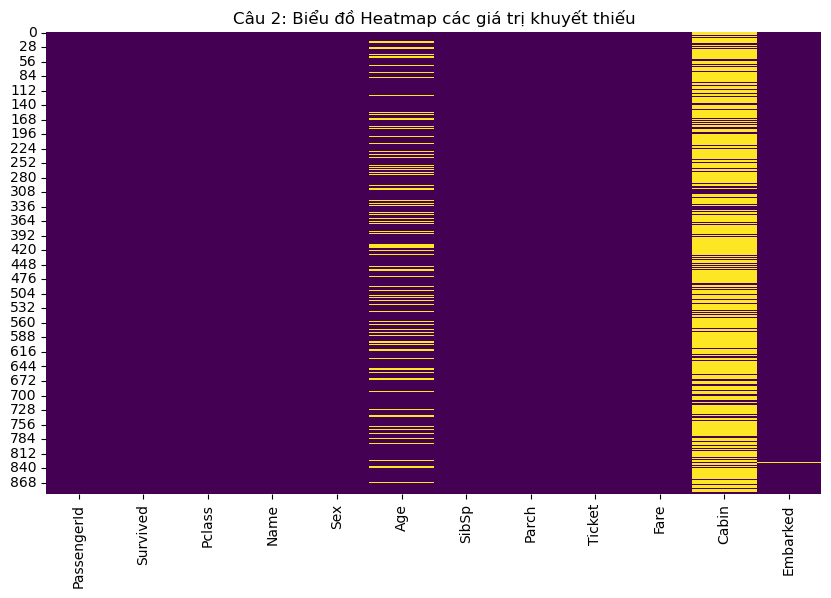

In [11]:
print("--- CÂU 2: THỐNG KÊ SỐ LƯỢNG DÒNG THIẾU ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Câu 2: Biểu đồ Heatmap các giá trị khuyết thiếu')
plt.show()

In [12]:
def split_names(data):
    data = data.copy()
    data[['firstName', 'secondName']] = data['Name'].str.split(',', n=1, expand=True)
    data['firstName'] = data['firstName'].str.strip()
    data['secondName'] = data['secondName'].str.strip()
    data.drop(columns=['Name'], inplace=True)
    return data

# Thực thi Câu 3
df = split_names(df)
print("--- CÂU 3: KẾT QUẢ SAU KHI TÁCH TÊN ---")
print(df[['firstName', 'secondName']].head(3))

--- CÂU 3: KẾT QUẢ SAU KHI TÁCH TÊN ---
   firstName                                  secondName
0     Braund                             Mr. Owen Harris
1    Cumings  Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                 Miss. Laina


In [13]:
def clean_sex(data):
    data = data.copy()
    data['Sex'] = data['Sex'].map({'male': 'M', 'female': 'F'})
    return data

# Thực thi Câu 4
df = clean_sex(df)
print("--- CÂU 4: KẾT QUẢ RÚT GỌN CỘT SEX ---")
print(df['Sex'].head(3))

--- CÂU 4: KẾT QUẢ RÚT GỌN CỘT SEX ---
0    M
1    F
2    F
Name: Sex, dtype: object


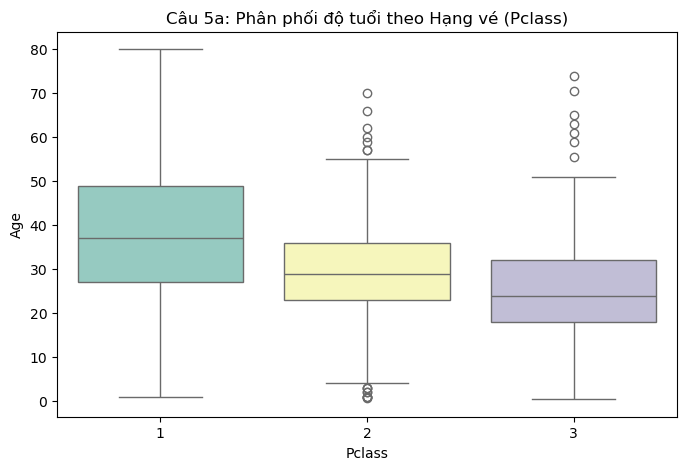


> Nhận xét Câu 5a & Quyết định:
- Nhóm Pclass cao hơn (Hạng 1) có tuổi trung vị cao hơn rõ rệt so với Hạng 2 và Hạng 3.
- Quyết định: Thay thế giá trị tuổi thiếu bằng tuổi trung bình của chính nhóm Pclass đó.

--- CÂU 5b: KIỂM TRA SỐ LƯỢNG Ô TRỐNG CỘT AGE SAU KHI ĐIỀN KHUYẾT ---
Số lượng ô trống còn lại: 0


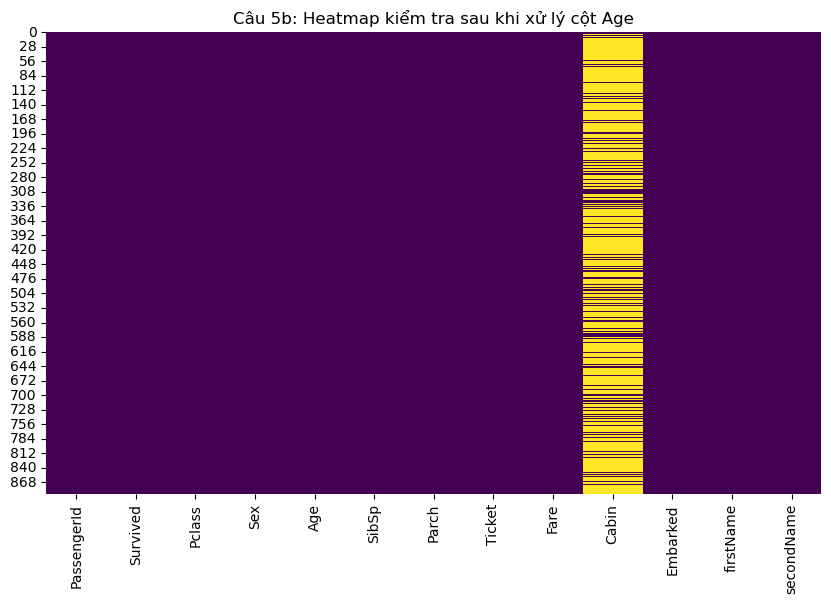

In [15]:
# --- Câu 5: Xử lý dữ liệu thiếu trên biến Age ---
# Câu 5a: Vẽ Boxplot phân phối tuổi theo Pclass
plt.figure(figsize=(8, 5))
# Đã sửa lỗi FutureWarning bằng cách thêm hue='Pclass' và legend=False
sns.boxplot(x='Pclass', y='Age', data=df, hue='Pclass', palette='Set3', legend=False)
plt.title('Câu 5a: Phân phối độ tuổi theo Hạng vé (Pclass)')
plt.show()

print("\n> Nhận xét Câu 5a & Quyết định:")
print("- Nhóm Pclass cao hơn (Hạng 1) có tuổi trung vị cao hơn rõ rệt so với Hạng 2 và Hạng 3.")
print("- Quyết định: Thay thế giá trị tuổi thiếu bằng tuổi trung bình của chính nhóm Pclass đó.")

# Câu 5b: Điền khuyết Age và vẽ lại Heatmap
def impute_age(data):
    data = data.copy()
    data['Age'] = data.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))
    return data

df = impute_age(df)
print("\n--- CÂU 5b: KIỂM TRA SỐ LƯỢNG Ô TRỐNG CỘT AGE SAU KHI ĐIỀN KHUYẾT ---")
print(f"Số lượng ô trống còn lại: {df['Age'].isnull().sum()}")

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Câu 5b: Heatmap kiểm tra sau khi xử lý cột Age')
plt.show()
print("\n" + "="*50 + "\n")

In [16]:
# --- Câu 6: Xây dựng biến phân lớp tuổi Agegroup ---
def create_age_group(data):
    data = data.copy()
    bins = [-1, 12, 18, 60, np.inf]
    labels = ['Kid', 'Teen', 'Adult', 'Older']
    data['Agegroup'] = pd.cut(data['Age'], bins=bins, labels=labels)
    return data

df = create_age_group(df)
print("--- CÂU 6: KẾT QUẢ PHÂN NHÓM TUỔI (AGEGROUP) ---")
print(df[['Age', 'Agegroup']].head(5))
print("\n" + "="*50 + "\n")

--- CÂU 6: KẾT QUẢ PHÂN NHÓM TUỔI (AGEGROUP) ---
    Age Agegroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult




In [17]:
# --- Câu 7: Tách danh xưng namePrefix ---
def extract_prefix(data):
    data = data.copy()
    data['namePrefix'] = data['secondName'].str.split('.').str[0].str.strip()
    return data

df = extract_prefix(df)
print("--- CÂU 7: THỐNG KÊ 5 DANH XƯNG XUẤT HIỆN NHIỀU NHẤT ---")
print(df['namePrefix'].value_counts().head(5))
print("\n" + "="*50 + "\n")

--- CÂU 7: THỐNG KÊ 5 DANH XƯNG XUẤT HIỆN NHIỀU NHẤT ---
namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Name: count, dtype: int64




In [18]:
# --- Câu 8: Khai thác đặc trưng familySize ---
def add_family_size(data):
    data = data.copy()
    data['familySize'] = 1 + data['SibSp'] + data['Parch']
    return data

df = add_family_size(df)
print("--- CÂU 8: KẾT QUẢ TẠO BIẾN KÍCH THƯỚC GIA ĐÌNH (FAMILYSIZE) ---")
print(df[['SibSp', 'Parch', 'familySize']].head(3))
print("\n" + "="*50 + "\n")

--- CÂU 8: KẾT QUẢ TẠO BIẾN KÍCH THƯỚC GIA ĐÌNH (FAMILYSIZE) ---
   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1




In [19]:
# --- Câu 9: Tạo đặc trưng Alone ---
def add_alone_feature(data):
    data = data.copy()
    data['Alone'] = np.where(data['familySize'] == 1, 1, 0)
    return data

df = add_alone_feature(df)
print("--- CÂU 9: KẾT QUẢ TẠO BIẾN ĐI MỘT MÌNH (ALONE) ---")
print(df[['familySize', 'Alone']].head(3))
print("\n" + "="*50 + "\n")

--- CÂU 9: KẾT QUẢ TẠO BIẾN ĐI MỘT MÌNH (ALONE) ---
   familySize  Alone
0           2      0
1           2      0
2           1      1




In [20]:
# --- Câu 10: Tách loại cabin typeCabin ---
def clean_cabin(data):
    data = data.copy()
    data['Cabin'] = data['Cabin'].fillna('Unknown')
    data['typeCabin'] = data['Cabin'].astype(str).str[0]
    return data

df = clean_cabin(df)
print("--- CÂU 10: THỐNG KÊ PHÂN LOẠI CABIN (TYPECABIN) ---")
print(df['typeCabin'].value_counts())
print("\n" + "="*50 + "\n")

--- CÂU 10: THỐNG KÊ PHÂN LOẠI CABIN (TYPECABIN) ---
typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64




In [25]:
# --- Câu 11: Loại bỏ dữ liệu thừa bằng cách tách Train/Test độc lập ---
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print("--- CÂU 11: KÍCH THƯỚC HAI TẬP DỮ LIỆU SAU KHI CHIA TÁCH ĐỘC LẬP ---")
print(f"Kích thước tập huấn luyện (Train Set): {train_set.shape}")
print(f"Kích thước tập đánh giá (Test Set):    {test_set.shape}")
print("\nHoàn thành Phần 1. Chuẩn bị chuyển sang Phần 2...\n")


# =====================================================================
# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA
# =====================================================================

print("=====================================================================")
print("PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA")
print("=====================================================================\n")

--- CÂU 11: KÍCH THƯỚC HAI TẬP DỮ LIỆU SAU KHI CHIA TÁCH ĐỘC LẬP ---
Kích thước tập huấn luyện (Train Set): (712, 18)
Kích thước tập đánh giá (Test Set):    (179, 18)

Hoàn thành Phần 1. Chuẩn bị chuyển sang Phần 2...

PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA



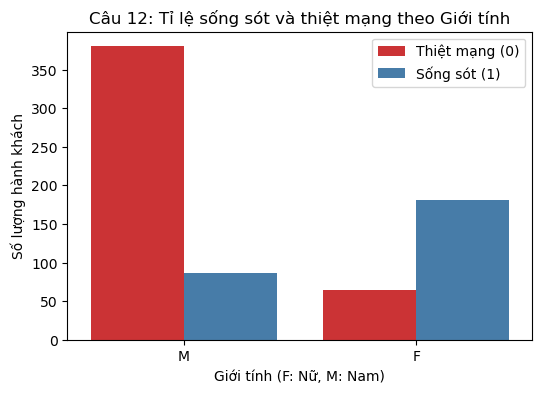

> Nhận xét Câu 12: Nữ giới (F) có tỷ lệ sống sót vượt trội so với nam giới (M).


In [26]:
# --- Câu 12: Tương quan tỷ lệ sống sót theo giới tính ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=train_set, palette='Set1')
plt.title('Câu 12: Tỉ lệ sống sót và thiệt mạng theo Giới tính')
plt.xlabel('Giới tính (F: Nữ, M: Nam)')
plt.ylabel('Số lượng hành khách')
plt.legend(['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()
print("> Nhận xét Câu 12: Nữ giới (F) có tỷ lệ sống sót vượt trội so với nam giới (M).")

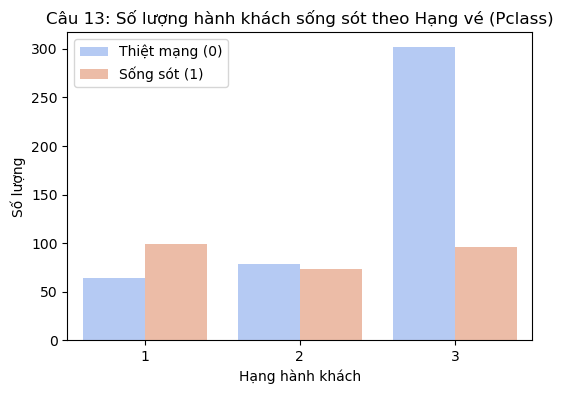

> Nhận xét Câu 13: Hành khách Hạng 1 có cơ hội sống sót cao nhất; Hạng 3 thiệt mạng nhiều nhất.


In [27]:
# --- Câu 13: Hành khách sống sót theo Pclass ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=train_set, palette='coolwarm')
plt.title('Câu 13: Số lượng hành khách sống sót theo Hạng vé (Pclass)')
plt.xlabel('Hạng hành khách')
plt.ylabel('Số lượng')
plt.legend(['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()
print("> Nhận xét Câu 13: Hành khách Hạng 1 có cơ hội sống sót cao nhất; Hạng 3 thiệt mạng nhiều nhất.")

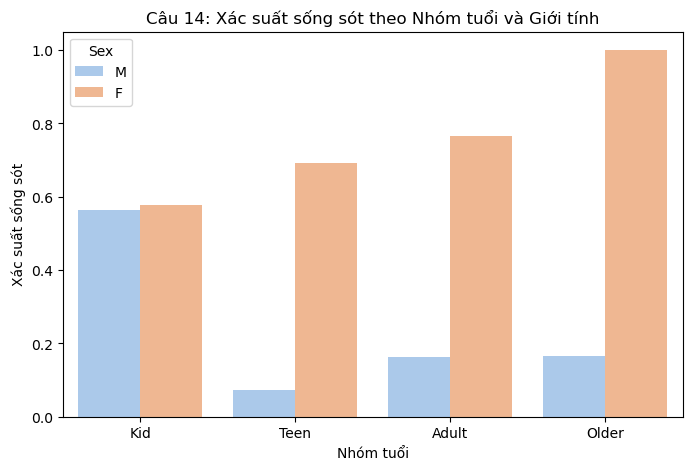

> Nhận xét Câu 14: Trẻ em (Kid) có cơ hội sống cao ở cả 2 giới. Nam giới trưởng thành có tỷ lệ sống rất thấp.


In [28]:
# --- Câu 14: Hành khách sống sót theo giới tính và nhóm tuổi ---
plt.figure(figsize=(8, 5))
sns.barplot(x='Agegroup', y='Survived', hue='Sex', data=train_set, errorbar=None, palette='pastel')
plt.title('Câu 14: Xác suất sống sót theo Nhóm tuổi và Giới tính')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Xác suất sống sót')
plt.show()
print("> Nhận xét Câu 14: Trẻ em (Kid) có cơ hội sống cao ở cả 2 giới. Nam giới trưởng thành có tỷ lệ sống rất thấp.")

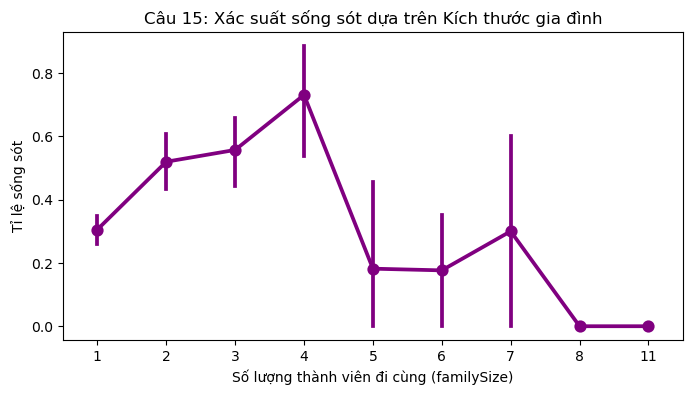

> Nhận xét Câu 15: Các gia đình nhỏ (2-4 người) dễ sống sót hơn người độc hành hoặc gia đình quá đông (>5 người).


In [30]:
# --- Câu 15: Xác suất sống sót dựa trên kích thước gia đình ---
plt.figure(figsize=(8, 4))
sns.pointplot(x='familySize', y='Survived', data=train_set, color='purple')
plt.title('Câu 15: Xác suất sống sót dựa trên Kích thước gia đình')
plt.xlabel('Số lượng thành viên đi cùng (familySize)')
plt.ylabel('Tỉ lệ sống sót')
plt.show()
print("> Nhận xét Câu 15: Các gia đình nhỏ (2-4 người) dễ sống sót hơn người độc hành hoặc gia đình quá đông (>5 người).")

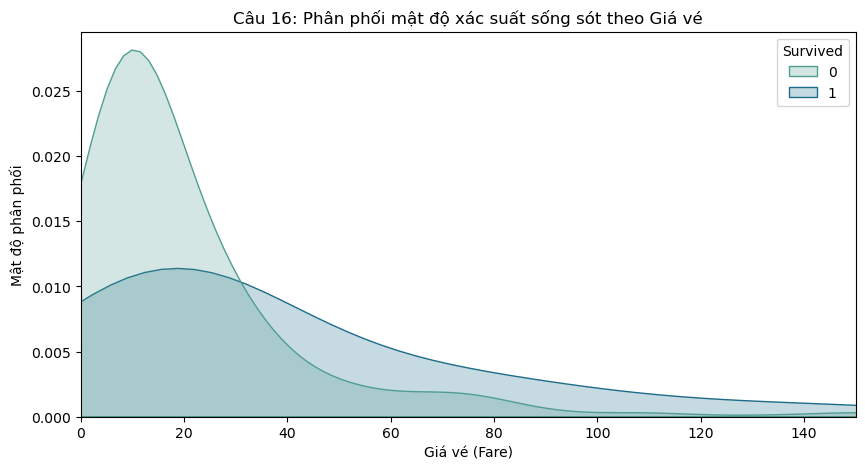

> Nhận xét Câu 16: Người mua vé giá rẻ (dưới 25 đơn vị) chiếm tỷ lệ tử vong cao nhất. Giá vé cao tăng cơ hội sống.


In [31]:
# --- Câu 16: Xác suất sống sót dựa trên giá vé ---
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train_set, x='Fare', hue='Survived', fill=True, palette='crest', common_norm=False)
plt.xlim(0, 150)
plt.title('Câu 16: Phân phối mật độ xác suất sống sót theo Giá vé')
plt.xlabel('Giá vé (Fare)')
plt.ylabel('Mật độ phân phối')
plt.show()
print("> Nhận xét Câu 16: Người mua vé giá rẻ (dưới 25 đơn vị) chiếm tỷ lệ tử vong cao nhất. Giá vé cao tăng cơ hội sống.")

ValueError: Could not interpret value `Pclass` for `x`. Value is a string, but `data` was not passed.

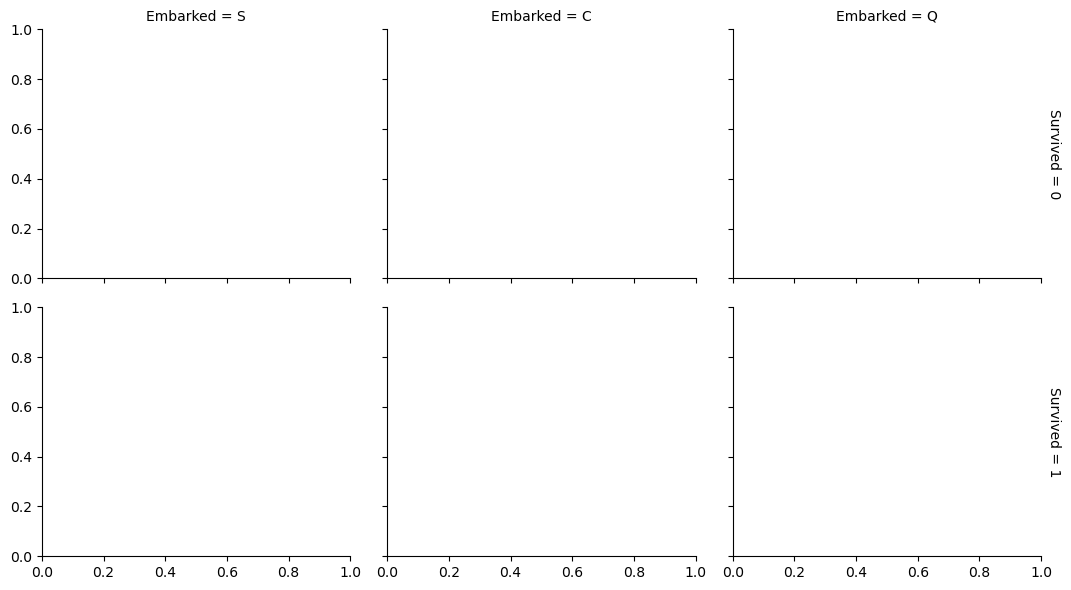

In [34]:
# --- Câu 17: Số người thiệt mạng và sống sót theo phân lớp Pclass và cảng cập bến (Embarked) ---

# Khởi tạo ma trận lưới FacetGrid
g = sns.FacetGrid(train_set, col="Embarked", row="Survived", margin_titles=True, height=3, aspect=1.2)

# SỬA LẠI ĐÂY: Khai báo rõ ràng x="Pclass" để Seaborn không bị nhận nhầm trục dữ liệu
g.map(sns.countplot, x="Pclass", order=[1, 2, 3], hue="Pclass", palette="muted", legend=False)

# Cấu hình căn chỉnh tiêu đề
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Câu 17: Thống kê Sống/Chết theo Hạng vé và Cảng cập bến')
plt.show()

print("> Nhận xét Câu 17: Cảng S có lượng người chết đông nhất (chủ yếu hạng 3). Cảng C có tỷ lệ sống sót của hạng 1 rất cao.")